# CNN-Based Ring Artifact Reduction — Per-Patient Training
Based off of the paper *A CNN-Based Hybrid Ring Artifact Reduction Algorithm for CT Images*
IEEE TRPMS 2020, Chen et al.

## Structure
For each patient folder (L067, L286, …):
1. 80 / 20 train/test split within that patient's images
2. Train a dedicated 5-layer CNN (25 epochs, Adam lr=0.02, batch 48)
3. Save training curve → `Colab_Models/{pid}_training_curve.png`
4. Run inference on all that patient's images using their own model
5. Save SSIM bar chart → `Colab_Models/{pid}_ssim.png`
6. Save model → `Colab_Models/ring_cnn_{pid}.pt`
7. Write CNN images → `medicalimaging/cnnimages/FD_1mm/…/{pid}/…`

## Drive layout expected
```
MyDrive/medicalimaging/
  artifactfree/FD_1mm/full_1mm/L067/full_1mm/*.IMA
  ringartifact/FD_1mm/full_1mm/L067/full_1mm/*.IMA
  precorrected/FD_1mm/full_1mm/L067/full_1mm/*.IMA
```

In [2]:
!pip install -q pydicom scikit-image tqdm pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 19.1 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os, re, random, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pydicom
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

warnings.filterwarnings('ignore', category=UserWarning)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [6]:
# ── Configuration ────────────────────────────────────────────────────────────
BASE        = '/content/drive/MyDrive/medicalimaging'
AF_ROOT     = f'{BASE}/artifactfree/FD_1mm'
RING_ROOT   = f'{BASE}/ringartifact/FD_1mm'
PRE_ROOT    = f'{BASE}/precorrected/FD_1mm'
CNN_ROOT    = f'{BASE}/cnnimages/FD_1mm'
SAVE_DIR    = '/content/drive/MyDrive/Colab_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Paper Section II-C parameters
PATCH_SIZE        = 64
PATCHES_PER_IMAGE = 20    # patches extracted per image per epoch build
BATCH_SIZE        = 48    # paper: batch size 48
EPOCHS            = 25  # paper: stops after 1000 iterations
LR                = 0.02  # paper: learning rate 0.02
TRAIN_FRAC        = 0.80  # 80/20 split within each patient
SEED              = 42
N_FEAT            = 32    # feature maps per layer
N_LAYERS          = 5     # convolutional layers

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
print('Config loaded.')

Config loaded.


In [7]:
# ── Helper functions ─────────────────────────────────────────────────────────

def glob_ima(root):
    root = Path(root)
    seen = set(); files = []
    for pat in ('*.ima','*.IMA','*.dcm','*.DCM'):
        for f in root.rglob(pat):
            if f not in seen: seen.add(f); files.append(f)
    return sorted(files)

def load_hu(path):
    ds = pydicom.dcmread(str(path))
    slope     = float(getattr(ds, 'RescaleSlope',     1.0))
    intercept = float(getattr(ds, 'RescaleIntercept', 0.0))
    return ds.pixel_array.astype(np.float64) * slope + intercept

def norm01(arr):
    """Min-max normalise full image to [0, 1] float32."""
    lo, hi = arr.min(), arr.max()
    if hi - lo < 1e-8:
        return np.zeros_like(arr, dtype=np.float32)
    return ((arr - lo) / (hi - lo)).astype(np.float32)

def save_dicom_hu(ds_template, new_hu, out_path):
    slope     = float(getattr(ds_template, 'RescaleSlope',     1.0))
    intercept = float(getattr(ds_template, 'RescaleIntercept', 0.0))
    stored    = np.round((new_hu - intercept) / slope).astype(np.int16)
    nd = ds_template.copy()
    nd.PixelData = stored.tobytes()
    nd.Rows = stored.shape[0]; nd.Columns = stored.shape[1]
    nd.BitsAllocated = 16; nd.BitsStored = 16
    nd.HighBit = 15; nd.PixelRepresentation = 1
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    nd.save_as(str(out_path))

def patient_id(path):
    """Extract Lxxx patient ID from any path component."""
    for part in Path(path).parts:
        if re.match(r'^L\d+$', part, re.IGNORECASE):
            return part.upper()
    return None

print('Helpers defined.')

Helpers defined.


In [8]:
# ── Discover patient folders and build per-patient triplet lists ──────────────
def find_case(p):
    p = Path(p)
    if p.exists(): return p
    alt = p.with_suffix(p.suffix.swapcase())
    return alt if alt.exists() else None

def build_patient_triplets(af_root, ring_root, pre_root):
    af_files = glob_ima(af_root)
    print(f'Total artifact-free files: {len(af_files)}')
    if not af_files:
        raise FileNotFoundError(f'No .IMA files found under {af_root}')

    by_patient = defaultdict(list)
    missing = 0
    for af in af_files:
        pid = patient_id(af)
        if pid is None: continue
        rel        = af.relative_to(af_root)
        ring_found = find_case(Path(ring_root) / rel)
        pre_found  = find_case(Path(pre_root)  / rel)
        if ring_found and pre_found:
            by_patient[pid].append((af, ring_found, pre_found))
        else:
            missing += 1

    print(f'Patients found: {sorted(by_patient.keys())}')
    print(f'Incomplete triplets skipped: {missing}')
    for pid, trips in sorted(by_patient.items()):
        print(f'  {pid}: {len(trips)} triplets')
    return by_patient

all_patients = build_patient_triplets(AF_ROOT, RING_ROOT, PRE_ROOT)

Total artifact-free files: 5936
Patients found: ['L067', 'L096', 'L109', 'L143', 'L192', 'L286', 'L291', 'L310', 'L333', 'L506']
Incomplete triplets skipped: 0
  L067: 560 triplets
  L096: 823 triplets
  L109: 318 triplets
  L143: 585 triplets
  L192: 600 triplets
  L286: 525 triplets
  L291: 856 triplets
  L310: 533 triplets
  L333: 610 triplets
  L506: 526 triplets


In [9]:
# ── Patch Dataset (Section II-C) ─────────────────────────────────────────────
class RingPatchDataset(Dataset):
    """
    Extracts PATCHES_PER_IMAGE random 64×64 patches per image.
    Input : 2-channel (x_ring, x_pre)  normalised per-image to [0,1].
    Target: x_free normalised with the SAME per-image stats as input.

    Normalisation note: norm01 is applied to the full image before patch
    extraction.  At inference time the full image is also norm01'd before
    tiling, keeping train/inference conventions identical.
    """
    def __init__(self, triplets, patch_size=PATCH_SIZE,
                 patches_per_img=PATCHES_PER_IMAGE, seed=SEED):
        self.triplets        = triplets
        self.patch_size      = patch_size
        self.patches_per_img = patches_per_img
        self.rng             = np.random.default_rng(seed)
        self._index          = self._build_index()

    def _build_index(self):
        idx = []; skipped = 0
        for i, (af, ring, pre) in enumerate(self.triplets):
            try:
                ds = pydicom.dcmread(str(af), stop_before_pixels=True)
                H, W = int(ds.Rows), int(ds.Columns)
            except Exception:
                H, W = 512, 512; skipped += 1
            p = self.patch_size
            if H < p or W < p: continue
            rows = self.rng.integers(0, H - p, size=self.patches_per_img)
            cols = self.rng.integers(0, W - p, size=self.patches_per_img)
            for r, c in zip(rows, cols):
                idx.append((i, int(r), int(c)))
        if skipped: print(f'  ({skipped} header reads fell back to 512×512)')
        return idx

    def __len__(self):  return len(self._index)

    def __getitem__(self, n):
        tri_idx, r, c = self._index[n]
        af_path, ring_path, pre_path = self.triplets[tri_idx]
        p = self.patch_size

        # Normalise each full image to [0,1] before patch extraction
        af_n   = norm01(load_hu(af_path))
        ring_n = norm01(load_hu(ring_path))
        pre_n  = norm01(load_hu(pre_path))

        inp = np.stack([ring_n[r:r+p, c:c+p],
                        pre_n [r:r+p, c:c+p]], axis=0).astype(np.float32)
        tgt = af_n[r:r+p, c:c+p][np.newaxis].astype(np.float32)
        return torch.from_numpy(inp), torch.from_numpy(tgt)

print('RingPatchDataset defined.')

RingPatchDataset defined.


In [10]:
# ── CNN Architecture (Section II-C, Fig. 3) ──────────────────────────────────
class RingCNN(nn.Module):
    """
    5-layer CNN.  Layers 1-4: Conv2d + ReLU.  Layer 5: Conv2d (no activation).
    Weights: L1 = 3×3×2×32, L2-L4 = 3×3×32×32, L5 = 3×3×32×1.
    Padding = 1 throughout so spatial size is preserved (64×64 in, 64×64 out).
    """
    def __init__(self, n_feat=N_FEAT, n_layers=N_LAYERS):
        super().__init__()
        layers = [nn.Conv2d(2, n_feat, 3, padding=1), nn.ReLU(inplace=True)]
        for _ in range(n_layers - 2):
            layers += [nn.Conv2d(n_feat, n_feat, 3, padding=1), nn.ReLU(inplace=True)]
        layers.append(nn.Conv2d(n_feat, 1, 3, padding=1))
        self.net = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x): return self.net(x)

# Quick sanity check
_m = RingCNN().to(device)
_x = torch.zeros(1, 2, 64, 64).to(device)
assert _m(_x).shape == (1, 1, 64, 64), "Shape mismatch"
n_params = sum(p.numel() for p in _m.parameters())
print(f'RingCNN: {n_params:,} parameters  ✓')
del _m, _x

RingCNN: 28,641 parameters  ✓


In [11]:
# ── Full-image inference (overlapping 64×64 tiles) ───────────────────────────
def cnn_infer(model, ring_hu, pre_hu):
    """
    Tile the full image with 64×64 patches (16-px overlap).
    Normalise each full image to [0,1] before tiling — consistent with training.
    Output is rescaled back to HU using the ring image's global min/max.

    Note: the model was trained to predict norm01(x_free), so the [0,1] output
    represents the artifact-free image in the ring image's value range
    (ring ≈ free in range, differing only in fine ring-artifact signal).
    """
    model.eval()
    H, W = ring_hu.shape
    TILE  = PATCH_SIZE      # 64
    STEP  = TILE - 16       # 48 px stride, 16 px overlap

    ring_n = norm01(ring_hu)
    pre_n  = norm01(pre_hu)

    out = np.zeros((H, W), dtype=np.float32)
    cnt = np.zeros((H, W), dtype=np.float32)

    def starts(size):
        s = list(range(0, size - TILE + 1, STEP))
        if not s or s[-1] + TILE < size: s.append(max(0, size - TILE))
        return s

    with torch.no_grad():
        for r in starts(H):
            for c in starts(W):
                t_ring = ring_n[r:r+TILE, c:c+TILE]
                t_pre  = pre_n [r:r+TILE, c:c+TILE]
                inp    = torch.from_numpy(
                    np.stack([t_ring, t_pre], axis=0)[np.newaxis]
                ).to(device)
                pred   = model(inp).squeeze().cpu().numpy()
                out[r:r+TILE, c:c+TILE] += pred
                cnt[r:r+TILE, c:c+TILE] += 1.0

    cnt = np.maximum(cnt, 1.0)
    out_01 = (out / cnt).astype(np.float64)

    # Inverse-normalise: map [0,1] back to HU using ring image range
    lo, hi = ring_hu.min(), ring_hu.max()
    return np.clip(out_01 * (hi - lo) + lo, lo, hi)

print('cnn_infer defined.')

cnn_infer defined.


In [12]:
# ── Per-patient training and inference ───────────────────────────────────────
#
# Resume-safe: if ring_cnn_{pid}.pt already exists in SAVE_DIR, that patient
# is considered fully done (training + inference + charts all saved) and is
# skipped.  Re-run this cell after a disconnection to continue from wherever
# the runtime stopped.
# ─────────────────────────────────────────────────────────────────────────────

def patient_is_done(pid):
    """
    A patient is considered complete when ALL of the following exist:
      • ring_cnn_{pid}.pt          — model checkpoint
      • {pid}_training_curve.png   — training curve
      • {pid}_ssim.png             — SSIM bar chart
    Requiring all three guards against a partial write (e.g. the model saved
    but Colab disconnected before inference finished writing the SSIM chart).
    """
    required = [
        Path(SAVE_DIR) / f'ring_cnn_{pid}.pt',
        Path(SAVE_DIR) / f'{pid}_training_curve.png',
        Path(SAVE_DIR) / f'{pid}_ssim.png',
    ]
    return all(p.exists() for p in required)


# ── Pre-run status report ─────────────────────────────────────────────────────
all_pids    = sorted(all_patients.keys())
done_pids   = [pid for pid in all_pids if patient_is_done(pid)]
todo_pids   = [pid for pid in all_pids if not patient_is_done(pid)]

print(f"Patients total : {len(all_pids)}  →  {all_pids}")
print(f"Already done   : {len(done_pids)}  →  {done_pids}")
print(f"Still to do    : {len(todo_pids)}  →  {todo_pids}")

if not todo_pids:
    print("\nAll patients complete. Nothing to do.")
else:
    print(f"\nStarting from: {todo_pids[0]}")


# ── Load any already-computed SSIM summaries from saved checkpoints ───────────
# So the aggregate chart at the end is correct even on a resumed run.
all_ssim_summaries = {}
for pid in done_pids:
    ckpt_path = Path(SAVE_DIR) / f'ring_cnn_{pid}.pt'
    try:
        ckpt = torch.load(ckpt_path, map_location='cpu')
        all_ssim_summaries[pid] = ckpt['ssim_means']
        print(f"  Loaded saved SSIM for {pid}: {ckpt['ssim_means']}")
    except Exception as e:
        print(f"  WARNING: could not load SSIM from {ckpt_path}: {e}")


# ── Main loop (only processes patients not yet done) ──────────────────────────
for pid in todo_pids:
    triplets = all_patients[pid]
    print(f'\n{"="*60}')
    print(f'  Patient {pid}  ({len(triplets)} images)')
    print(f'{"="*60}')

    # ── 1. Split ──────────────────────────────────────────────────
    random.shuffle(triplets)
    n_train  = max(1, int(len(triplets) * TRAIN_FRAC))
    tr_trips = triplets[:n_train]
    te_trips = triplets[n_train:]
    print(f'  Train: {len(tr_trips)}  |  Test: {len(te_trips)}')

    # ── 2. Datasets & loaders ─────────────────────────────────────
    train_ds = RingPatchDataset(tr_trips, seed=SEED)
    test_ds  = RingPatchDataset(te_trips, seed=SEED+1)
    print(f'  Train patches: {len(train_ds):,}  |  Test patches: {len(test_ds):,}')

    if len(train_ds) == 0:
        print(f'  WARNING: no patches for {pid}, skipping.')
        continue

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=2,
                              pin_memory=True, drop_last=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2,
                              pin_memory=True, drop_last=False)

    # ── 3. Model, loss, optimiser ─────────────────────────────────
    model     = RingCNN().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    train_losses, val_losses = [], []
    best_val   = float('inf')
    best_state = None

    # ── 4. Training loop ──────────────────────────────────────────
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running = 0.0
        for inp, tgt in train_loader:
            inp, tgt = inp.to(device), tgt.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inp), tgt)
            loss.backward()
            optimizer.step()
            running += loss.item() * inp.size(0)
        train_loss = running / len(train_ds)

        if len(test_ds) > 0:
            model.eval(); running = 0.0
            with torch.no_grad():
                for inp, tgt in test_loader:
                    inp, tgt = inp.to(device), tgt.to(device)
                    running += criterion(model(inp), tgt).item() * inp.size(0)
            val_loss = running / len(test_ds)
        else:
            val_loss = train_loss

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 100 == 0 or epoch == 1:
            print(f'  [{pid}] Epoch {epoch:4d}/{EPOCHS}  '
                  f'train={train_loss:.2e}  val={val_loss:.2e}')

    model.load_state_dict(best_state)
    print(f'  [{pid}] Training done. Best val MSE: {best_val:.2e}')

    # ── 5. Training curve ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 5))
    ep_x = range(1, len(train_losses) + 1)
    ax.semilogy(ep_x, train_losses, color='#1f77b4', lw=1.5, label='train')
    ax.semilogy(ep_x, val_losses,   color='#ff7f0e', lw=1.0, ls='--',
                marker='+', markevery=max(1, EPOCHS//50), ms=4, label='val')
    ax.set_xlabel('training epoch', fontsize=12)
    ax.set_ylabel('energy',         fontsize=12)
    ax.set_title(f'objective — {pid}', fontsize=13)
    ax.legend(fontsize=11); ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.set_xlim(0, EPOCHS)
    plt.tight_layout()
    curve_path = f'{SAVE_DIR}/{pid}_training_curve.png'
    fig.savefig(curve_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)
    print(f'  Saved training curve → {curve_path}')

    # ── 6. Inference on ALL patient images → cnnimages/ ───────────
    ssim_rows = []
    for af_path, ring_path, pre_path in tqdm(triplets,
                                              desc=f'  {pid} inference',
                                              unit='img', leave=False):
        rel      = ring_path.relative_to(RING_ROOT)
        out_path = Path(CNN_ROOT) / rel

        ds_ring = pydicom.dcmread(str(ring_path))
        ring_hu = load_hu(ring_path)
        pre_hu  = load_hu(pre_path)
        af_hu   = load_hu(af_path)

        cnn_hu  = cnn_infer(model, ring_hu, pre_hu)

        dr = af_hu.max() - af_hu.min()
        if dr > 0:
            ssim_rows.append({
                'file'     : str(rel),
                'ssim_ring': ssim(af_hu, ring_hu, data_range=dr),
                'ssim_pre' : ssim(af_hu, pre_hu,  data_range=dr),
                'ssim_cnn' : ssim(af_hu, cnn_hu,  data_range=dr),
            })
        save_dicom_hu(ds_ring, cnn_hu, out_path)

    df_pid = pd.DataFrame(ssim_rows)
    means  = df_pid[['ssim_ring','ssim_pre','ssim_cnn']].mean()
    stds   = df_pid[['ssim_ring','ssim_pre','ssim_cnn']].std()
    all_ssim_summaries[pid] = means.to_dict()
    print(f'  [{pid}] SSIM  ring={means.ssim_ring:.4f}  '
          f'pre={means.ssim_pre:.4f}  cnn={means.ssim_cnn:.4f}')

    # ── 7. SSIM bar chart ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))
    labels = ['Ring Artifact', 'WF Precorrected', 'CNN Output']
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    vals   = [means.ssim_ring, means.ssim_pre, means.ssim_cnn]
    errs   = [stds.ssim_ring,  stds.ssim_pre,  stds.ssim_cnn]
    bars = ax.bar(labels, vals, color=colors, edgecolor='black',
                  linewidth=0.7, yerr=errs, capsize=4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Mean SSIM'); ax.set_title(f'SSIM Comparison — {pid}')
    ax.set_ylim(max(0, min(vals) - 0.08), min(1.0, max(vals) + 0.06))
    ax.grid(axis='y', ls='--', alpha=0.5)
    plt.tight_layout()
    ssim_path = f'{SAVE_DIR}/{pid}_ssim.png'
    fig.savefig(ssim_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)

    # ── 8. Save model (written LAST — marks this patient as done) ─
    # The model is saved after inference and charts so that patient_is_done()
    # only returns True once everything for this patient is on Drive.
    model_path = f'{SAVE_DIR}/ring_cnn_{pid}.pt'
    torch.save({
        'patient_id'       : pid,
        'model_state_dict' : model.state_dict(),
        'optimizer_state'  : optimizer.state_dict(),
        'train_losses'     : train_losses,
        'val_losses'       : val_losses,
        'best_val_mse'     : best_val,
        'ssim_means'       : means.to_dict(),
        'n_train_images'   : len(tr_trips),
        'n_test_images'    : len(te_trips),
    }, model_path)
    print(f'  Saved model → {model_path}  ✓  ({pid} complete)')

print('\n' + '='*60)
print(f'All patients done.  ({len(all_patients)} total)')


Patients total : 10  →  ['L067', 'L096', 'L109', 'L143', 'L192', 'L286', 'L291', 'L310', 'L333', 'L506']
Already done   : 10  →  ['L067', 'L096', 'L109', 'L143', 'L192', 'L286', 'L291', 'L310', 'L333', 'L506']
Still to do    : 0  →  []

All patients complete. Nothing to do.
  Loaded saved SSIM for L067: {'ssim_ring': 0.9271939374839983, 'ssim_pre': 0.853382700327681, 'ssim_cnn': 0.8954353535919003}
  Loaded saved SSIM for L096: {'ssim_ring': 0.934119500350953, 'ssim_pre': 0.8665011681485766, 'ssim_cnn': 0.9052487862036388}
  Loaded saved SSIM for L109: {'ssim_ring': 0.9246003537126456, 'ssim_pre': 0.8664458160490232, 'ssim_cnn': 0.8694688198712592}
  Loaded saved SSIM for L143: {'ssim_ring': 0.9155356194692494, 'ssim_pre': 0.8218027174124233, 'ssim_cnn': 0.854995792035093}
  Loaded saved SSIM for L192: {'ssim_ring': 0.9334274918910126, 'ssim_pre': 0.869998179295323, 'ssim_cnn': 0.346903413279426}
  Loaded saved SSIM for L286: {'ssim_ring': 0.9199426690696451, 'ssim_pre': 0.860208472679

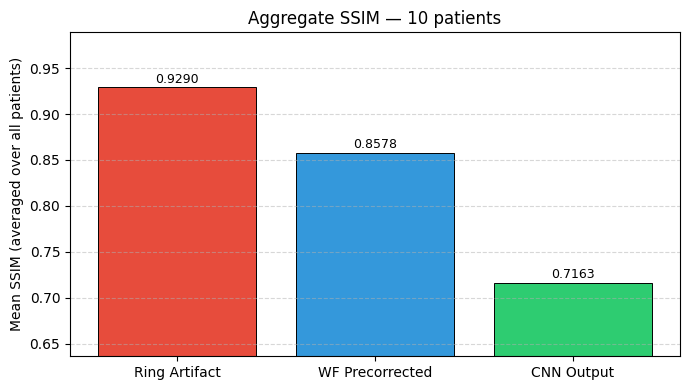

Aggregate SSIM chart saved → /content/drive/MyDrive/Colab_Models/aggregate_ssim.png

Final aggregate means:
  Ring Artifact  : 0.9290
  WF Precorrected: 0.8578
  CNN Output     : 0.7163
Per-patient CSV saved → /content/drive/MyDrive/Colab_Models/ssim_per_patient.csv


,ssim_ring,ssim_pre,ssim_cnn
patient,,,
L067,0.9272,0.8534,0.8954
L096,0.9341,0.8665,0.9052
L109,0.9246,0.8664,0.8695
L143,0.9155,0.8218,0.8550
L192,0.9334,0.8700,0.3469
L286,0.9199,0.8602,0.2528
L291,0.9290,0.8543,0.9098
L310,0.9269,0.8341,0.3080
L333,0.9365,0.8763,0.9302


In [13]:
# ── Aggregate SSIM chart (mean across all patients) ──────────────────────────
if all_ssim_summaries:
    agg_ring = np.mean([v['ssim_ring'] for v in all_ssim_summaries.values()])
    agg_pre  = np.mean([v['ssim_pre']  for v in all_ssim_summaries.values()])
    agg_cnn  = np.mean([v['ssim_cnn']  for v in all_ssim_summaries.values()])

    fig, ax = plt.subplots(figsize=(7, 4))
    labels = ['Ring Artifact', 'WF Precorrected', 'CNN Output']
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    vals   = [agg_ring, agg_pre, agg_cnn]
    bars = ax.bar(labels, vals, color=colors,
                  edgecolor='black', linewidth=0.7)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Mean SSIM (averaged over all patients)')
    ax.set_title(f'Aggregate SSIM — {len(all_ssim_summaries)} patients')
    ax.set_ylim(max(0, min(vals) - 0.08), min(1.0, max(vals) + 0.06))
    ax.grid(axis='y', ls='--', alpha=0.5)
    plt.tight_layout()
    agg_path = f'{SAVE_DIR}/aggregate_ssim.png'
    fig.savefig(agg_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Aggregate SSIM chart saved → {agg_path}')
    print(f'\nFinal aggregate means:')
    print(f'  Ring Artifact  : {agg_ring:.4f}')
    print(f'  WF Precorrected: {agg_pre:.4f}')
    print(f'  CNN Output     : {agg_cnn:.4f}')

    # Summary CSV
    df_agg = pd.DataFrame(all_ssim_summaries).T
    df_agg.index.name = 'patient'
    csv_path = f'{SAVE_DIR}/ssim_per_patient.csv'
    df_agg.to_csv(csv_path)
    print(f'Per-patient CSV saved → {csv_path}')
    display(df_agg.round(4))